
# Function Approximation with Value Methods
# Semi-Gradient SARSA with Tile Coding on MountainCar-v0

In this lab, we solve Gymnasium's MountainCar-v0 using linear function approximation. MountainCar has a continuous state space: position and velocity.
Because position and velocity can take many real-number values, a tabular method would require an impossible number of states. Instead of storing one value for every exact state, we build features from the state using tile coding.

Tile coding works like placing several slightly shifted grids over the state space.
Each grid activates one tile, and the combination of active tiles becomes the feature vector.
This lets nearby states share some weights, which helps the agent generalize from one state to similar states.

# Import libraries

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque


# Create the Environment and Inspect the State Space

This first code cell creates MountainCar-v0 and prints the observation and action spaces. This is important because function approximation starts with understanding what the raw observation looks like. Here, the raw state has two numbers: position and velocity.


In [2]:
env = gym.make("MountainCar-v0")

print("Observation space:", env.observation_space)
print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)

env.close()

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Observation low: [-1.2  -0.07]
Observation high: [0.6  0.07]
Action space: Discrete(3)
Number of actions: 3


The environment confirms why function approximation is needed. The observation is not a single state number. It is a two-dimensional continuous vector with position and velocity. If I tried to build a normal Q-table, I would need one row for every possible position and velocity combination. Since real numbers can take infinitely many values, this is not practical. Tile coding gives a compromise: it keeps the learning method simple and linear, but it still allows nearby states to share information.

# Tile Coding

Tile coding creates several overlapping grids over the same continuous state space. Each grid is slightly shifted. For one state, exactly one tile becomes active in each tiling. If there are 8 tilings, then 8 features are active. This gives the agent a richer representation than using only one grid.

In [3]:
class TileCoder:
    def __init__(self, low, high, num_tilings=8, tiles_per_dim=(8, 8)):
        self.low = np.array(low, dtype=np.float64)
        self.high = np.array(high, dtype=np.float64)
        self.num_tilings = int(num_tilings)
        self.tiles_per_dim = np.array(tiles_per_dim, dtype=np.int64)
        self.num_dims = len(self.low)
        self.tiles_per_tiling = int(np.prod(self.tiles_per_dim))
        self.total_features = self.num_tilings * self.tiles_per_tiling
        self.tile_width = (self.high - self.low) / (self.tiles_per_dim - 1)
        self.offsets = self._build_offsets()

    def _build_offsets(self):
        offsets = []
        for tiling in range(self.num_tilings):
            fraction = tiling / self.num_tilings
            offset = fraction * self.tile_width
            offsets.append(offset)
        return np.array(offsets)

    def get_active_indices(self, state):
        state = np.array(state, dtype=np.float64)
        active_indices = []

        for tiling in range(self.num_tilings):
            shifted_state = state + self.offsets[tiling]
            ratios = (shifted_state - self.low) / (self.high - self.low)
            tile_coords = np.floor(ratios * self.tiles_per_dim).astype(int)
            tile_coords = np.clip(tile_coords, 0, self.tiles_per_dim - 1)

            local_index = np.ravel_multi_index(tile_coords, self.tiles_per_dim)
            global_index = tiling * self.tiles_per_tiling + local_index
            active_indices.append(global_index)

        return np.array(active_indices, dtype=np.int64)

    def get_feature_vector(self, state):
        features = np.zeros(self.total_features)
        active_indices = self.get_active_indices(state)
        features[active_indices] = 1.0
        return features

This tile coder does not simply chop the state space once. It creates multiple overlapping versions of the state space. That matters because a single grid can create harsh boundaries. For example, two very similar states might fall into different tiles and look completely unrelated to the agent. With overlapping tilings, similar states still share some active features. This helps the agent generalize smoothly.
The sparse feature idea is also computationally efficient. The full feature vector may have hundreds or thousands of possible features, but only one tile per tiling is active for a given state. With 8 tilings, only 8 features are active at a time. This means learning can update only the relevant weights instead of changing everything.


# Test the Tile Coder

This cell checks whether the tile coder is working. I create a tile coder with 8 tilings and 8×8 tiles, then I pass in one sample MountainCar state.

In [4]:
low = np.array([-1.2, -0.07])
high = np.array([0.6, 0.07])

tile_coder = TileCoder(low=low, high=high, num_tilings=8, tiles_per_dim=(8, 8))

sample_state = np.array([-0.5, 0.02])
active_indices = tile_coder.get_active_indices(sample_state)
feature_vector = tile_coder.get_feature_vector(sample_state)

print("Total number of features:", tile_coder.total_features)
print("Active tile indices:", active_indices)
print("Number of active features:", int(feature_vector.sum()))
print("Feature vector shape:", feature_vector.shape)

Total number of features: 512
Active tile indices: [ 29  93 157 221 285 349 414 486]
Number of active features: 8
Feature vector shape: (512,)


This outcome validates the tile coder's functionality. Because of the setup's eight tilings, each of which has an 8x8 grid, there are 512 features in all. The whole feature space is 8 × 64 = 512 features as each tiling has 64 tiles. The active tile indices [-0.5, 0.02] indicate which particular tiles are triggered by the sample MountainCar condition. Given that there are eight tilings, the state activates precisely eight tiles, one from each. This explains why the result indicates that eight characteristics are active. The state is represented as a long binary vector with 512 potential points, but only 8 of them are activated, according to the feature vector shape (512).

# Define the Semi-Gradient SARSA Agent

Define the Semi-Gradient SARSA Agent

In [5]:
class SemiGradientSarsaAgent:
    def __init__(self, env, tile_coder, alpha=0.1, gamma=1.0, epsilon=0.1, seed=42):
        self.env = env
        self.tile_coder = tile_coder
        self.alpha = alpha / tile_coder.num_tilings
        self.gamma = gamma
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)
        self.num_actions = env.action_space.n
        self.weights = np.zeros((self.num_actions, tile_coder.total_features))

    def q_value(self, state, action):
        active_indices = self.tile_coder.get_active_indices(state)
        return np.sum(self.weights[action, active_indices])

    def q_values(self, state):
        active_indices = self.tile_coder.get_active_indices(state)
        return np.sum(self.weights[:, active_indices], axis=1)

    def choose_action(self, state):
        if self.rng.random() < self.epsilon:
            return self.env.action_space.sample()
        values = self.q_values(state)
        max_value = np.max(values)
        best_actions = np.flatnonzero(values == max_value)
        return int(self.rng.choice(best_actions))

    def update(self, state, action, reward, next_state, next_action, done):
        active_indices = self.tile_coder.get_active_indices(state)
        current_q = np.sum(self.weights[action, active_indices])

        if done:
            target = reward
        else:
            next_q = self.q_value(next_state, next_action)
            target = reward + self.gamma * next_q

        delta = target - current_q
        self.weights[action, active_indices] += self.alpha * delta

        return delta


This class is the heart of the lab. Instead of building a huge table, the agent stores one weight vector per action. For MountainCar, there are three actions, so the weight matrix has three rows. Each row represents how valuable different state features are for that action.
The update is local and simple. If the car is in a state where certain tiles are active, only those tile weights are changed.

# Training Function

This function trains semi-gradient SARSA.

In [6]:
def train_sarsa(config, episodes=500, seed=42):
    env = gym.make("MountainCar-v0")
    low = env.observation_space.low
    high = env.observation_space.high

    tile_coder = TileCoder(
        low=low,
        high=high,
        num_tilings=config["num_tilings"],
        tiles_per_dim=config["tiles_per_dim"]
    )

    agent = SemiGradientSarsaAgent(
        env=env,
        tile_coder=tile_coder,
        alpha=config["alpha"],
        gamma=config["gamma"],
        epsilon=config["epsilon"],
        seed=seed
    )

    episode_lengths = []
    episode_returns = []
    td_errors = []

    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        action = agent.choose_action(state)

        total_reward = 0
        steps = 0
        done = False

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if done:
                next_action = None
            else:
                next_action = agent.choose_action(next_state)

            delta = agent.update(state, action, reward, next_state, next_action, done)

            total_reward += reward
            steps += 1
            td_errors.append(abs(delta))

            state = next_state
            action = next_action

        episode_lengths.append(steps)
        episode_returns.append(total_reward)

    env.close()

    results = {
        "agent": agent,
        "tile_coder": tile_coder,
        "episode_lengths": np.array(episode_lengths),
        "episode_returns": np.array(episode_returns),
        "td_errors": np.array(td_errors),
        "config": config
    }

    return results

The episode length is the main performance measure here. Since MountainCar gives a reward of -1 for every time step, shorter episodes mean better performance. If the agent reaches the goal quickly, the episode length goes down and the total return becomes less negative. If the agent fails to reach the goal, the episode usually lasts the maximum 200 steps.
At the start, the agent does not know that it must first move left to build momentum, then swing right to climb the hill. A greedy-looking action early on may not be the best long-term strategy. The agent must learn a momentum-building policy through repeated experience.


# Train the Baseline Configuration

The baseline uses 8 tilings and 8×8 tiles, as requested in the assignment. I use alpha = 0.4 before dividing by the number of tilings inside the agent.

In [7]:
baseline_config = {
    "name": "8 tilings, 8x8 tiles",
    "num_tilings": 8,
    "tiles_per_dim": (8, 8),
    "alpha": 0.4,
    "gamma": 1.0,
    "epsilon": 0.1
}

baseline_results = train_sarsa(baseline_config, episodes=500, seed=42)

print("First 10 episode lengths:", baseline_results["episode_lengths"][:10])
print("Last 10 episode lengths:", baseline_results["episode_lengths"][-10:])
print("Average length over first 50 episodes:", np.mean(baseline_results["episode_lengths"][:50]))
print("Average length over last 50 episodes:", np.mean(baseline_results["episode_lengths"][-50:]))

First 10 episode lengths: [200 200 200 200 200 200 200 200 200 200]
Last 10 episode lengths: [119 166 173 162 123 157 132 114 111 168]
Average length over first 50 episodes: 196.02
Average length over last 50 episodes: 149.88


This result shows that the baseline semi-gradient SARSA agent is learning, but it has not fully mastered the environment yet. In the first 10 episodes, every episode lasted 200 steps, which is the maximum limit in MountainCar. This means the agent was not reaching the goal early in training. That makes sense because the weights started at zero, so the agent had not learned the momentum-building strategy yet. The average length over the first 50 episodes was 196.02, showing that the agent was mostly unsuccessful at the beginning. By the last 50 episodes, the average dropped to 149.88 steps. With fewer steps, the automobile is accomplishing the objective more quickly, which is a definite improvement. A number of successful shorter episodes, including steps 111, 114, 119, and 123, may also be seen in the remaining 10 episode lengths.

# Moving Average Helper

This function smooths the learning curve so the trend is easier to see. Without smoothing, episode lengths may jump up and down because exploration still happens.

In [8]:
def moving_average(values, window=25):
    values = np.array(values)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

# Plot Episodes-to-Goal Learning Curve

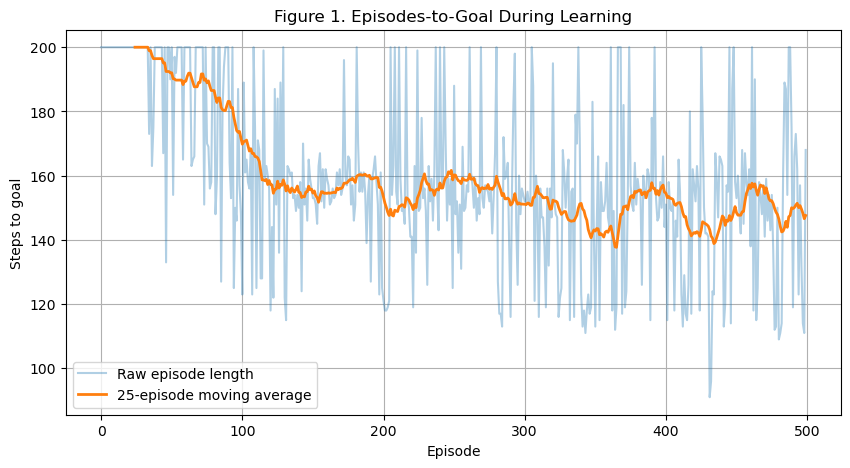

In [9]:
episode_lengths = baseline_results["episode_lengths"]
smoothed_lengths = moving_average(episode_lengths, window=25)

plt.figure(figsize=(10, 5))
plt.plot(episode_lengths, alpha=0.35, label="Raw episode length")
plt.plot(np.arange(len(smoothed_lengths)) + 24, smoothed_lengths, linewidth=2, label="25-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Steps to goal")
plt.title("Figure 1. Episodes-to-Goal During Learning")
plt.legend()
plt.grid(True)
plt.show()

in Figure 1, we see the semi-gradient SARSA agent's improvement over 500 training cycles. The episode's initial duration stays close to MountainCar's maximum of 200 steps. This shows that the agent was still studying without a clear strategy and was not achieving the objective at hand.   The moving average falls rapidly from 200 steps to 155 steps after 50 to 120 episodes. This indicates that the agent began to pick up the momentum-building behavior required to ascend the correct slope. The agent occasionally failed or took too long due to exploration and inconsistent learning, as seen by the extremely noisy raw episode durations with several spikes back to 200 steps. On the other hand, the actual trend is more evident in the orange moving-average line. The agent developed a better policy, but there is still opportunity for development, as seen by the curve's overall improvement and stabilization at 145–160 steps.

# Create Value Function Grid

This function evaluates the learned value function over the whole position-velocity space. For each state, it computes the Q-value for every action and keeps the maximum.

In [10]:
def compute_value_grid(agent, position_points=80, velocity_points=80):
    positions = np.linspace(agent.env.observation_space.low[0], agent.env.observation_space.high[0], position_points)
    velocities = np.linspace(agent.env.observation_space.low[1], agent.env.observation_space.high[1], velocity_points)

    value_grid = np.zeros((velocity_points, position_points))
    policy_grid = np.zeros((velocity_points, position_points), dtype=int)

    for i, velocity in enumerate(velocities):
        for j, position in enumerate(positions):
            state = np.array([position, velocity])
            q_values = agent.q_values(state)
            value_grid[i, j] = np.max(q_values)
            policy_grid[i, j] = np.argmax(q_values)

    return positions, velocities, value_grid, policy_grid

# Plot Learned Value Function Heatmap

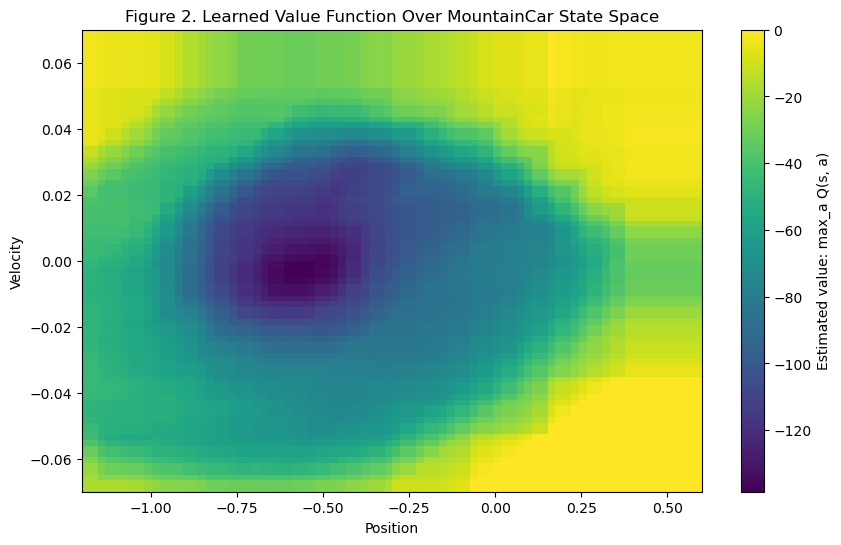

In [11]:
agent = baseline_results["agent"]
positions, velocities, value_grid, policy_grid = compute_value_grid(agent)

plt.figure(figsize=(10, 6))
plt.imshow(
    value_grid,
    origin="lower",
    extent=[positions.min(), positions.max(), velocities.min(), velocities.max()],
    aspect="auto"
)
plt.colorbar(label="Estimated value: max_a Q(s, a)")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Figure 2. Learned Value Function Over MountainCar State Space")
plt.show()

Figure 2 shows the learned value function across the MountainCar state space using position and velocity. The yellow regions have values closer to 0, which means the agent believes those states are better because they are closer to reaching the goal. The darker purple and blue regions have more negative values, meaning the agent expects to need more steps from those states. The lowest-value area appears around the middle-left valley region, near position -0.6 and velocity close to 0. This makes sense because the car is stuck low in the valley with little momentum, so it still needs to build speed before reaching the flag. The brighter areas on the right side show better states because the car is closer to the goal. The bright areas at high positive or negative velocities also suggest that momentum is valuable.

# Plot Learned Policy Across State Space

The policy plot shows which action the agent prefers in each region of the state space. The action meanings are:
0 = accelerate left
1 = no acceleration
2 = accelerate right


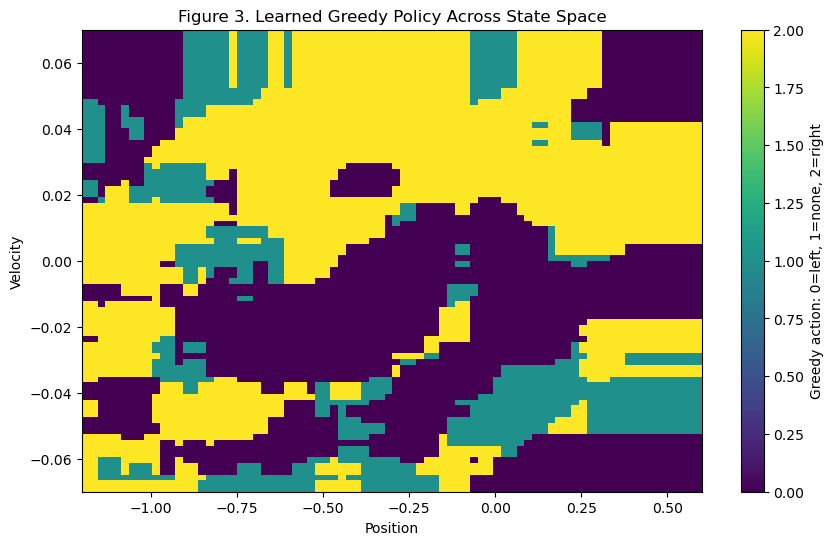

In [12]:
plt.figure(figsize=(10, 6))
plt.imshow(
    policy_grid,
    origin="lower",
    extent=[positions.min(), positions.max(), velocities.min(), velocities.max()],
    aspect="auto"
)
plt.colorbar(label="Greedy action: 0=left, 1=none, 2=right")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Figure 3. Learned Greedy Policy Across State Space")
plt.show()

figure 3: The greedy action the agent learns for every combination of location and velocity. The three alternative actions are represented by the colors: push left (0), do nothing (1), and push right (2). The policy is not one simple action everywhere, which is important because MountainCar cannot be solved by always pushing right. Instead, the agent must use momentum. The large dark regions show where the agent prefers pushing left, usually to build backward momentum. The large yellow regions show where the agent prefers pushing right, especially when the car has enough velocity or is positioned to climb toward the goal. The smaller green/blue areas show moments where doing nothing is selected, although this action appears less dominant. The patchy pattern suggests that the learned policy is useful but not perfectly smooth. 

# Sample Trajectories Overlaid on the Value Function

This function runs a greedy policy from selected starting positions and records the trajectory. The trajectories are then plotted on top of the value function heatmap.

In [15]:
def run_greedy_trajectory(agent, start_state, max_steps=200):
    env = gym.make("MountainCar-v0")
    state, info = env.reset()

    env.unwrapped.state = np.array(start_state, dtype=np.float64)

    trajectory = []
    done = False
    steps = 0

    while not done and steps < max_steps:
        current_state = np.array(env.unwrapped.state, dtype=np.float64)
        trajectory.append(current_state)

        action = int(np.argmax(agent.q_values(current_state)))
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        steps += 1

    trajectory.append(np.array(env.unwrapped.state, dtype=np.float64))

    env.close()

    return np.array(trajectory)

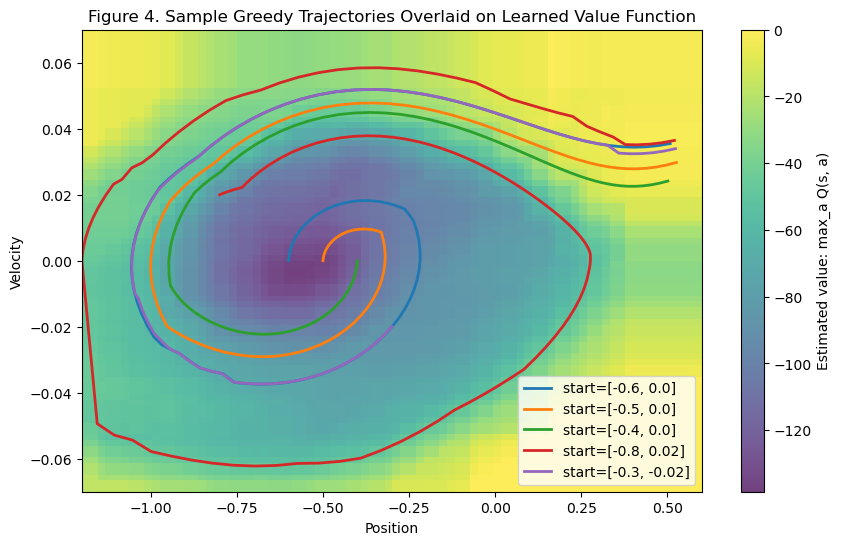

In [16]:
start_states = [
    [-0.6, 0.0],
    [-0.5, 0.0],
    [-0.4, 0.0],
    [-0.8, 0.02],
    [-0.3, -0.02]
]

plt.figure(figsize=(10, 6))

plt.imshow(
    value_grid,
    origin="lower",
    extent=[positions.min(), positions.max(), velocities.min(), velocities.max()],
    aspect="auto",
    alpha=0.75
)

for start_state in start_states:
    trajectory = run_greedy_trajectory(agent, start_state)
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linewidth=2,
        label=f"start={start_state}"
    )

plt.colorbar(label="Estimated value: max_a Q(s, a)")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Figure 4. Sample Greedy Trajectories Overlaid on Learned Value Function")
plt.legend()
plt.show()

Figure 4 illustrates the behavior of the learnt greedy strategy from various initial conditions when superimposed on the estimated value function. Near the right side of the image, the trajectories often start in lower-value areas, represented by deeper blue and purple, and go toward higher-value yellow areas. This indicates that the policy is directing the vehicle from less promising states toward states that are closer to the objective, which is encouraging. The proper MountainCar approach is shown in a number of trajectories that circle through the valley before rising upward: the vehicle must gain speed by going back and forth before it can reach the summit of the right slope. This is particularly evident in the lengthier red trajectory, which begins at [-0.8, 0.02] and swings considerably before ascending. Additionally, the shorter inner routes imply that some initial states already have more momentum and require less correction.

# Experiment with Different Tile Coding Configurations

Now I test multiple feature configurations. This directly answers the assignment requirement about how number of tilings, tile sizes, and feature design affect learning speed, final performance, and computational cost.

In [17]:
experiment_configs = [
    {
        "name": "4 tilings, 8x8 tiles",
        "num_tilings": 4,
        "tiles_per_dim": (8, 8),
        "alpha": 0.4,
        "gamma": 1.0,
        "epsilon": 0.1
    },
    {
        "name": "8 tilings, 8x8 tiles",
        "num_tilings": 8,
        "tiles_per_dim": (8, 8),
        "alpha": 0.4,
        "gamma": 1.0,
        "epsilon": 0.1
    },
    {
        "name": "8 tilings, 10x10 tiles",
        "num_tilings": 8,
        "tiles_per_dim": (10, 10),
        "alpha": 0.4,
        "gamma": 1.0,
        "epsilon": 0.1
    },
    {
        "name": "16 tilings, 8x8 tiles",
        "num_tilings": 16,
        "tiles_per_dim": (8, 8),
        "alpha": 0.4,
        "gamma": 1.0,
        "epsilon": 0.1
    }
]

all_results = {}

for config in experiment_configs:
    print("Training:", config["name"])
    all_results[config["name"]] = train_sarsa(config, episodes=500, seed=42)

print("Finished all experiments.")

Training: 4 tilings, 8x8 tiles
Training: 8 tilings, 8x8 tiles
Training: 8 tilings, 10x10 tiles
Training: 16 tilings, 8x8 tiles
Finished all experiments.


# Plot Convergence Curves for Feature Configurations

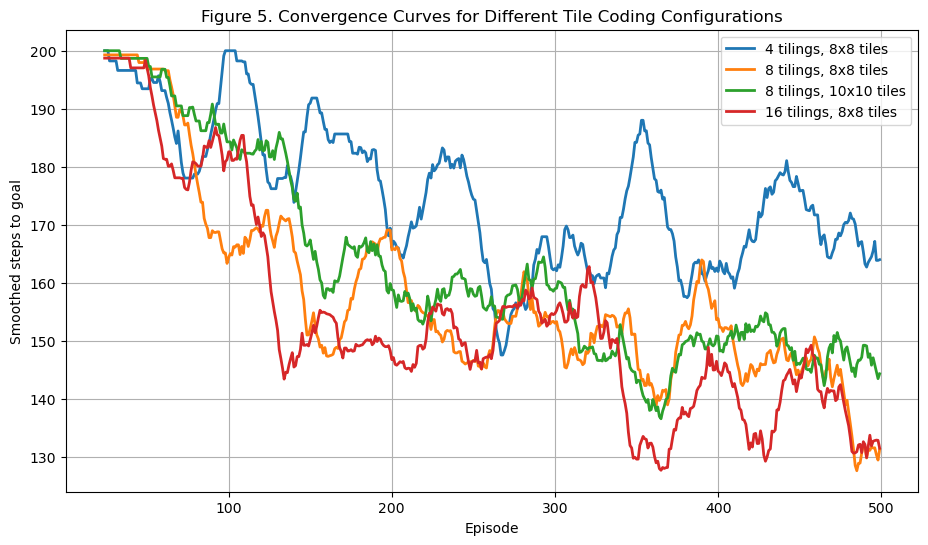

In [18]:
plt.figure(figsize=(11, 6))

for name, results in all_results.items():
    smoothed = moving_average(results["episode_lengths"], window=25)
    x_values = np.arange(len(smoothed)) + 24
    plt.plot(x_values, smoothed, linewidth=2, label=name)

plt.xlabel("Episode")
plt.ylabel("Smoothed steps to goal")
plt.title("Figure 5. Convergence Curves for Different Tile Coding Configurations")
plt.legend()
plt.grid(True)
plt.show()

Figure 5 compares how different tile coding settings affect learning performance. All configurations begin near 200 steps, meaning the agents initially struggled to reach the goal. As training continues, the curves generally move downward, showing that each agent learned a better MountainCar strategy over time. The 4-tiling configuration performs the worst overall because it stays higher and more unstable, suggesting that fewer tilings did not give the agent enough representation detail. The 8 tilings with 8×8 tiles performs better and reaches around 130 steps near the end. The 8 tilings with 10×10 tiles also improves, but it stays around 145 steps, possibly because the finer grid needs more experience to learn well. The 16 tilings with 8×8 tiles shows strong improvement and reaches some of the lowest values, but it is also more computationally expensive.

# Create a Clean Comparison Table

In [19]:
summary_rows = []

for name, results in all_results.items():
    config = results["config"]
    episode_lengths = results["episode_lengths"]
    tile_coder = results["tile_coder"]

    first_50_avg = np.mean(episode_lengths[:50])
    last_50_avg = np.mean(episode_lengths[-50:])
    best_50_avg = np.min([np.mean(episode_lengths[i:i+50]) for i in range(len(episode_lengths) - 49)])
    total_features = tile_coder.total_features
    active_features = tile_coder.num_tilings

    summary_rows.append({
        "Configuration": name,
        "Total Features": total_features,
        "Active Features per State": active_features,
        "Avg Steps First 50": round(first_50_avg, 2),
        "Avg Steps Last 50": round(last_50_avg, 2),
        "Best 50-Episode Avg": round(best_50_avg, 2),
        "Improvement": round(first_50_avg - last_50_avg, 2)
    })

summary_table = pd.DataFrame(summary_rows)
summary_table

,Configuration,Total Features,Active Features per State,Avg Steps First 50,Avg Steps Last 50,Best 50-Episode Avg,Improvement
0,"4 tilings, 8x8 tiles",256,4,196.72,166.26,157.72,30.46
1,"8 tilings, 8x8 tiles",512,8,198.98,137.62,136.76,61.36
2,"8 tilings, 10x10 tiles",800,8,199.34,147.34,142.50,52.00
3,"16 tilings, 8x8 tiles",1024,16,198.52,136.72,131.64,61.80


The comparison table illustrates the effects of feature design on computational cost, learning speed, and end performance. The 4-tiling arrangement was the least expensive computationally since it contained the fewest total features (256) and just four active features per state. It did, however, display the least advancement, falling from 196.72 steps to 166.26 steps. With an increase of 61.36 steps to reach 137.62 steps, 8 tilings with 8x8 tiles turned out significantly better. This implies that a stronger state representation was obtained using eight tilings. Despite having more features overall—800—the 8 tilings with 10x10 tiles performed worse in the end than the 8x8 variant, perhaps because the finer grid required more training. With 1024 features, the 16-tiling setup got the best end average of 136.72 steps.

# Visualize TD Error During Training

TD error shows how surprised the agent is during learning. Large TD errors mean the target and current prediction are far apart. Smaller TD errors suggest the value estimates are becoming more stable.

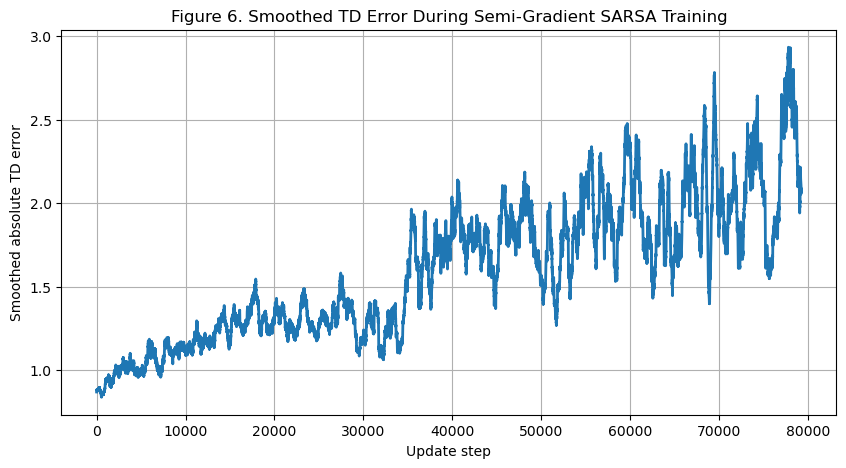

In [20]:
td_errors = baseline_results["td_errors"]
smoothed_td = moving_average(td_errors, window=500)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_td, linewidth=2)
plt.xlabel("Update step")
plt.ylabel("Smoothed absolute TD error")
plt.title("Figure 6. Smoothed TD Error During Semi-Gradient SARSA Training")
plt.grid(True)
plt.show()

Figure 6: 
The smoothed absolute TD error during semi-gradient SARSA training is depicted in Figure 6. The TD error quantifies the discrepancy between the updated target and the agent's current Q-value estimate. The TD error does not diminish continuously in this figure. Rather, it increases from around 0.9 at the beginning of training to more than 2.0 at the conclusion, with many spikes. This does not always mean that the agent did not succeed. TD error may increase in reinforcement learning because the agent is exploring through epsilon-greedy actions, changing its policy, and visiting new regions of the state space. As the agent grows better, it can arrive to states nearer the objective that yield distinct value goals, resulting in more extensive updates. Learning is still active and not entirely steady, according to the noisy increasing trend.




- Document how feature design choices (number of tilings, tile sizes, offsets) affect learning speed, final performance, and computational cost. Explain why MountainCar is difficult for tabular methods (hint: continuous state space would require infinite states) and how function approximation enables solving it.



Feature design strongly affects how well the MountainCar agent learns. The number of tilings controls how many overlapping grids describe each state. The agent has fewer active features and a lower computational cost when there are fewer tilings, like 4, but learning is slower and ultimate performance is worse since the representation is less detailed. The agent receives a more detailed description of the same position and velocity with more tilings, such 8 or 16, which enhances learning and makes the policy more fluid. However, more tilings also mean more active weights must be updated at every step, increasing computation. Tile size also matters. Coarser tiles, such as 8×8, generalize more broadly because many similar states share the same tiles. Finer tiles, such as 10×10, give more precision, but they create more total features and may require more episodes to learn well. Offsets are also important because shifted tilings prevent sharp boundaries. They allow nearby states to share some active features, which improves generalization.
MountainCar is difficult for tabular methods because its state space is continuous. There are many potential states since the car's location and velocity are actual quantities. It is difficult to provide a value for every potential position-velocity pair in a standard Q-table. Function approximation solves this by representing states with features instead of exact table entries. Tile coding converts continuous states into sparse binary feature vectors, and the agent learns weights for those features. This allows learning to generalize across similar states and makes MountainCar manageable without needing an infinite table.
